4221 делится на 21, возможно 21 выстрелов по 201 приемников
4221 делится на 201, возможно 201 выстрелов по 21 приемников


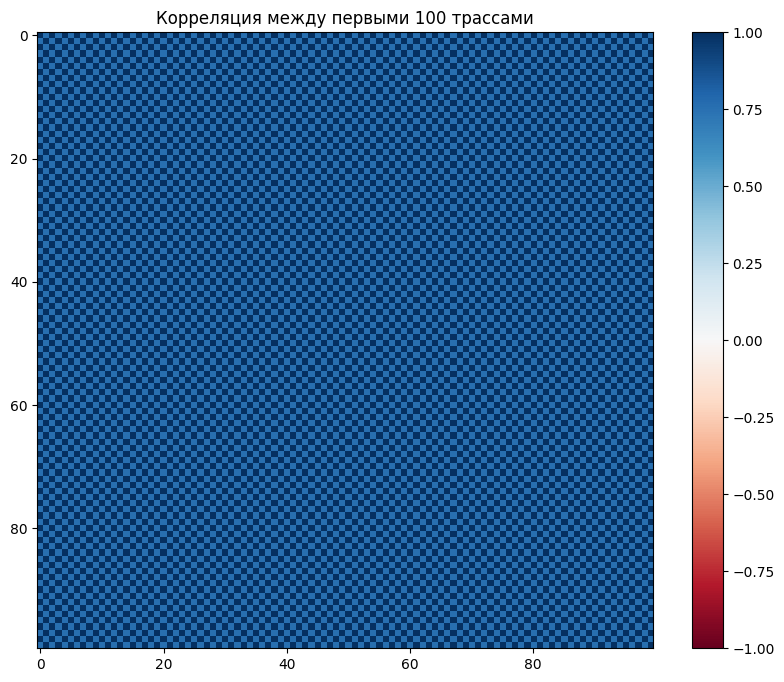

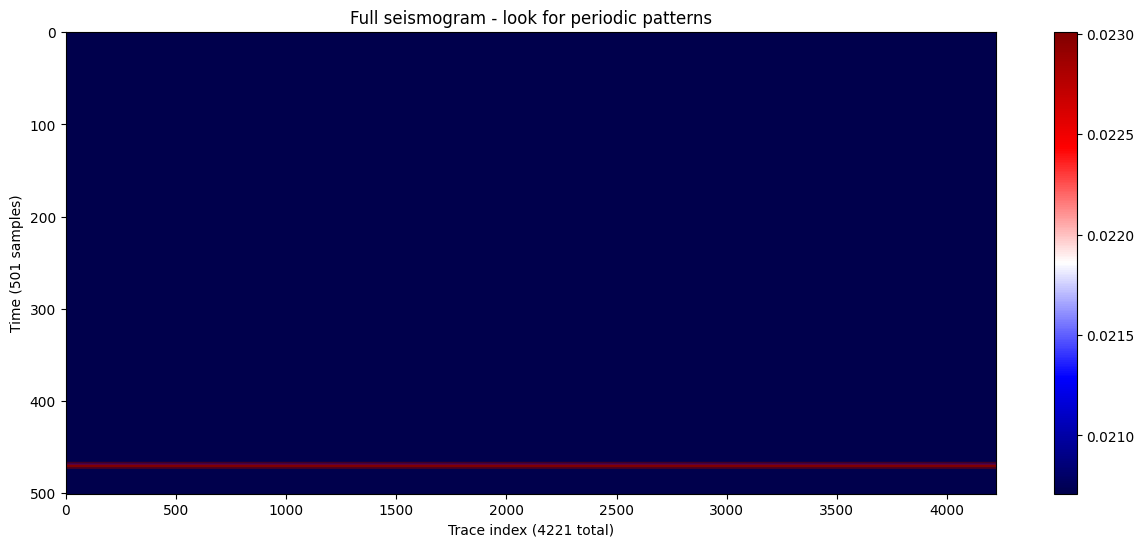

ModuleNotFoundError: No module named 'scipy'

In [5]:
import segyio
import numpy as np

with segyio.open("data\input.sgy", "r", ignore_geometry=True) as f:
    data = np.array([trace for trace in f.trace]).T  # [time, receivers]

<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:4: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Роман\AppData\Local\Temp\ipykernel_13552\4131506787.py:4: SyntaxWarning: invalid escape sequence '\i'
  with segyio.open("data\input.sgy", "r", ignore_geometry=True) as f:


In [7]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array("data\input.sgy")

# 1. Проверка на периодичность (должна быть если 21 выстрел)
n_shots_test = [21, 42, 61, 69, 201]
for n in n_shots_test:
    if 4221 % n == 0:
        print(f"4221 делится на {n}, возможно {n} выстрелов по {4221//n} приемников")

# 2. Посмотреть корреляцию между трассами
corr = np.corrcoef(data[:, :100].T)  # первые 100 трасс
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar()
plt.title("Корреляция между первыми 100 трассами")
plt.show()

# 3. Визуализировать как 2D профиль
plt.figure(figsize=(15, 6))
plt.imshow(data, aspect='auto', cmap='seismic', 
           vmin=-np.percentile(data, 1), 
           vmax=np.percentile(data, 99))
plt.colorbar()
plt.xlabel('Trace index (4221 total)')
plt.ylabel('Time (501 samples)')
plt.title('Full seismogram - look for periodic patterns')
plt.show()

# 4. Посмотреть спектр
from scipy.fft import fft
spec = np.abs(fft(data, axis=0)).mean(axis=1)
plt.semilogy(spec[:100])
plt.title('Average frequency spectrum')
plt.show()

4221 делится на 21, возможно 21 выстрелов по 201 приемников
4221 делится на 201, возможно 201 выстрелов по 21 приемников


<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:4: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Роман\AppData\Local\Temp\ipykernel_13552\2254675520.py:4: SyntaxWarning: invalid escape sequence '\i'
  data = np.array("data\input.sgy")


IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

In [9]:
pip install obspy

  Using cached certifi-2026.4.22-py3-none-any.whl.metadata (2.5 kB)
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   -- ------------------------------------- 0.8/14.8 MB 6.7 MB/s eta 0:00:03
   ------ --------------------------------- 2.4/14.8 MB 6.7 MB/s eta 0:00:02
   ---------- ----------------------------- 3.9/14.8 MB 7.1 MB/s eta 0:00:02
   -------------- ------------------------- 5.5/14.8 MB 7.3 MB/s eta 0:00:02
   ------------------- -------------------- 7.1/14.8 MB 7.2 MB/s eta 0:00:02
   ---------------------- ----------------- 8.4/14.8 MB 6.9 MB/s eta 0:00:01
   ------------------------- -------------- 9.4/14.8 MB 6.8 MB/s eta 0:00:01
   ----------------------------- ---------- 11.0/14.8 MB 6.7 MB/s eta 0:00:01
   --------------------------------- ------ 12.3/14.8 MB 6.6 MB/s eta 0:00:01
   ------------------------------------ --- 13.4/14.8 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------  14.7/14.8 MB 6.5 MB/s eta 0:00:01
   --------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:4: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Роман\AppData\Local\Temp\ipykernel_13552\2010707920.py:4: SyntaxWarning: invalid escape sequence '\i'
  st = read("data\input.sgy")


4221 Trace(s) in Stream:

Seq. No. in line:    0 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:00.500000Z | 1000.0 Hz, 501 samples
...
(4219 other traces)
...
Seq. No. in line:    0 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:00.500000Z | 1000.0 Hz, 501 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


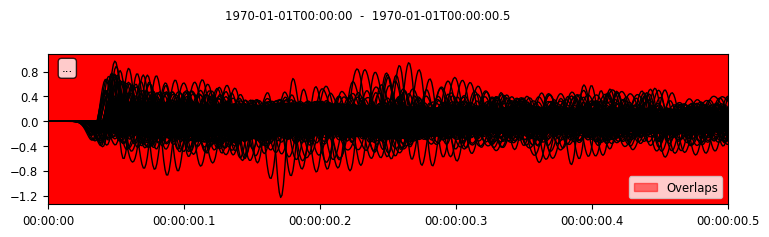

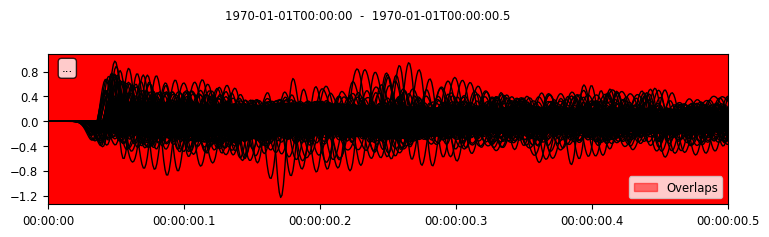

In [11]:
from obspy import read

# Чтение sgy-файла (или segy)
st = read("data\input.sgy")

# Вывод информации о трассах в консоль
print(st)

# Визуализация всех сейсмограмм в файле
st.plot()

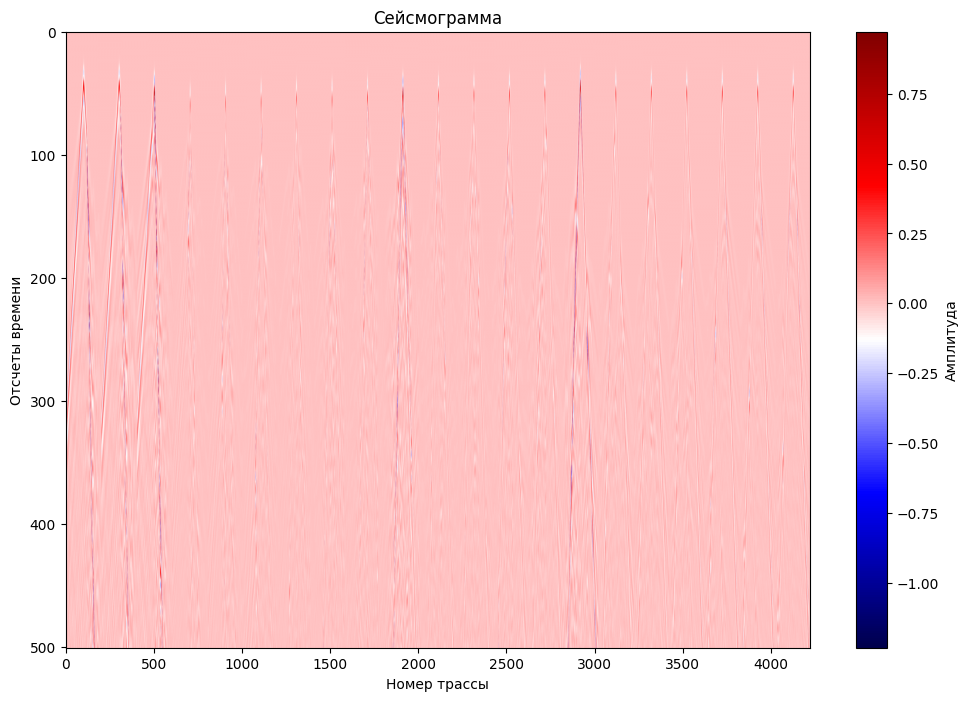

In [17]:
import segyio
import numpy as np
import matplotlib.pyplot as plt

file_path = r"data\input.sgy"  # r-строка защищает от проблем с обратным слэшем

with segyio.open(file_path, "r", ignore_geometry=True) as f:
    # f.trace.raw[:] считывает ВСЕ трассы в память как 2D массив (трассы x время)
    seismic_data = f.trace.raw[:] 

# Для imshow нам нужно повернуть матрицу (Время по вертикали, Трассы по горизонтали)
# seismic_data.T делает именно это (из трассы х время -> время х трассы)
plt.figure(figsize=(12, 8))
plt.imshow(seismic_data.T, cmap="seismic", aspect="auto") # vmin/vmax лучше настроить по факту
plt.title("Сейсмограмма")
plt.xlabel("Номер трассы")
plt.ylabel("Отсчеты времени")
plt.colorbar(label="Амплитуда")
plt.show()

In [19]:
import segyio
import numpy as np

file_path = r"data\input.sgy"

with segyio.open(file_path, "r", ignore_geometry=True) as f:
    # 1. Считываем точные размеры напрямую из файла SEG-Y
    actual_n_traces = f.tracecount  # общее количество трасс в файле
    actual_n_samples = f.samples.size  # точное количество отсчетов времени в ОДНОЙ трассе
    
    print(f"В файле всего трасс: {actual_n_traces}")
    print(f"Длина одной трассы (отсчетов времени): {actual_n_samples}")
    
    # 2. Загружаем данные. Segyio вернет массив формы (трассы, время)
    # Для вашего файла это будет, например, матрица размером (4221, 501)
    seismic_data_2d = f.trace.raw[:]

# 3. Теперь делим общее количество трасс на ваши 21 сейсмограммы
num_seismic = 21
traces_per_seismic = actual_n_traces // num_seismic

print(f"Трасс в одной сейсмограмме: {traces_per_seismic}")

# 4. Безопасный reshape на основе РЕАЛЬНЫХ данных из файла
# Изменяем форму на: [Количество сейсмограмм, Трассы, Время]
X = seismic_data_2d.reshape(num_seismic, traces_per_seismic, actual_n_samples)

# 5. Меняем оси местами, чтобы Время было по вертикали (как принято в нейросетях для сейсмики)
# Было: [21, Трассы, Время] -> Стало: [21, Время, Трассы]
X = np.transpose(X, (0, 2, 1))

# 6. Добавляем канал для нейросети [21, Время, Трассы, 1]
X = np.expand_dims(X, axis=-1)

print("Итоговая размерность тензора X для ML:", X.shape)


В файле всего трасс: 4221
Длина одной трассы (отсчетов времени): 501
Трасс в одной сейсмограмме: 201
Итоговая размерность тензора X для ML: (21, 501, 201, 1)


In [20]:
import torch
import torch.nn as nn

class FWIMLP(nn.Module):
    def __init__(self, input_dim=100701, output_dim=100701):
        super(FWIMLP, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, output_dim) # Выход — плоская карта скоростей
        )
        
    def forward(self, x):
        # x имеет форму [Batch, 1, 501, 201]
        batch_size = x.size(0)
        x = x.view(batch_size, -1) # Сплющиваем в [Batch, 100701]
        out = self.mlp(x)
        return out.view(batch_size, 1, 501, 201) # Возвращаем форму картинки
